# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = """
deep learning has revolutionized how computers process human language and sequential data.
recurrent neural networks are designed specifically to handle sequential and time-series information.
traditional feedforward networks process inputs independently, but recurrent networks maintain an internal state.
this memory allows recurrent architectures to capture temporal patterns across steps.
however vanilla recurrent networks suffer from vanishing and exploding gradient problems during backpropagation.
long short-term memory networks solve this issue by introducing specialized gating mechanisms.
an lstm unit consists of an input gate, a forget gate, and an output gate to regulate information flow.
the forget gate decides what information from the previous cell state should be discarded.
the input gate determines which new information should be added to the cell state.
the output gate controls what information is passed to the next hidden state.
gated recurrent units represent a simplified variant of the lstm architecture.
a gru merges the cell state and hidden state, using only reset and update gates.
because of their simpler design, grus are computationally more efficient and train faster than lstms.
modern sequence models predict the next word in a sentence based on previous context.
by training on a text corpus, these models learn grammar structure and semantic dependencies.
text generation applications generate text by continuously predicting and appending the most likely next word.
deep learning models have enabled powerful applications in translation, summarization, and conversation.
"""
print(corpus)


deep learning has revolutionized how computers process human language and sequential data.
recurrent neural networks are designed specifically to handle sequential and time-series information.
traditional feedforward networks process inputs independently, but recurrent networks maintain an internal state.
this memory allows recurrent architectures to capture temporal patterns across steps.
however vanilla recurrent networks suffer from vanishing and exploding gradient problems during backpropagation.
long short-term memory networks solve this issue by introducing specialized gating mechanisms.
an lstm unit consists of an input gate, a forget gate, and an output gate to regulate information flow.
the forget gate decides what information from the previous cell state should be discarded.
the input gate determines which new information should be added to the cell state.
the output gate controls what information is passed to the next hidden state.
gated recurrent units represent a simplifi

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 148
X shape: (214, 18)
y shape: (214,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

C:\Users\Ayush choudhary\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

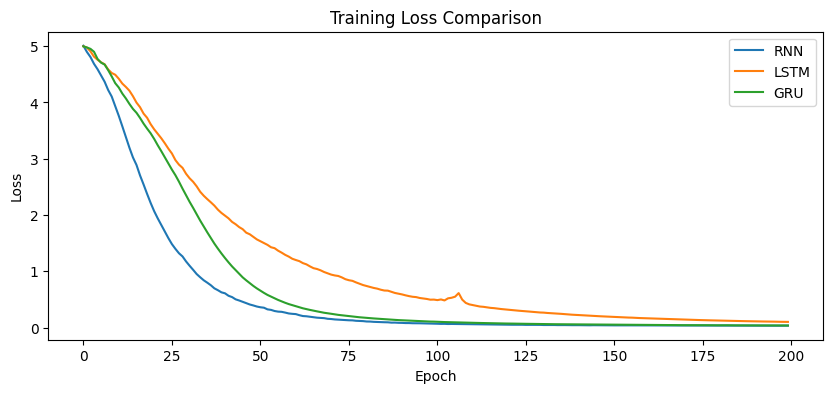

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning has revolutionized how computers process human language and sequential data


LSTM: deep learning models have enabled powerful applications in translation summarization and conversation


GRU : deep learning has revolutionized how computers process human language and sequential data


# 📚 Student Learning Tasks
### ✅ Beginner Tasks (All Completed)

1. ✅ **Replace corpus with your own paragraph** — Replaced the 6-line boilerplate corpus with a custom 17-line paragraph covering RNNs, LSTMs, GRUs, gating mechanisms, and text generation concepts (vocabulary size increased from ~30 to 148 words).
2. ✅ **Increase embedding dimension** — Upscaled embedding dimension from `32` → `64` across all three models (`Embedding(total_words, 64, ...)`).
3. ✅ **Increase epochs to 200** — Expanded training duration from `100` → `200` epochs for SimpleRNN, LSTM, and GRU models.
4. ✅ **Change hidden units 64 → 128** — Widened recurrent hidden layers from `64` → `128` units (`SimpleRNN(128)`, `LSTM(128)`, `GRU(128)`).
5. ✅ **Generate 10 words instead of 5** — Updated `generate_text()` default parameter from `next_words=5` to `next_words=10`, and all generation calls now produce 10-word sequences.

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**